# Gender-Based Violence in Nepal (2019-2026) - EDA

## Section 0: Setup & Data Loading

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

print("pandas:", pd.__version__)
print("numpy:", np.__version__)

pandas: 3.0.3
numpy: 2.4.6


In [3]:
df = pd.read_csv("../data/raw/GenderBasedVoilence2019-2026 Nepal.csv")
df['Date'] = pd.to_datetime(df['Date'], format = '%m/%d/%Y')

print("Shape:", df.shape)
df.head()

Shape: (42337, 11)


,Date,Fiscal_Year,Province_No,Province,District,Police_Station,Crime_Category,Victim_Demographic,Cases_Reported,Status,Year
0,2019-01-01,2018/19,1,Koshi,Morang,Urlabari PS,Rape,Woman,6,Under Investigation,2019
1,2019-01-01,2018/19,1,Koshi,Sunsari,WCSC Inaruwa,Rape,Girl-Child,4,Decided,2019
2,2019-01-01,2018/19,1,Koshi,Jhapa,WCSC Birtamod,Rape,Woman,2,Decided,2019
3,2019-01-01,2018/19,1,Koshi,Dhankuta,Dhankuta Sadar PS,Rape,Woman,1,Under Investigation,2019
4,2019-01-01,2018/19,1,Koshi,Sankhuwasabha,WCSC Khandbari,Rape,Girl-Child,5,Decided,2019


## Section 1: Data Overview & Quality Check

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 42337 entries, 0 to 42336
Data columns (total 11 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                42337 non-null  datetime64[us]
 1   Fiscal_Year         42337 non-null  str           
 2   Province_No         42337 non-null  int64         
 3   Province            42337 non-null  str           
 4   District            42337 non-null  str           
 5   Police_Station      42337 non-null  str           
 6   Crime_Category      42337 non-null  str           
 7   Victim_Demographic  42337 non-null  str           
 8   Cases_Reported      42337 non-null  int64         
 9   Status              42337 non-null  str           
 10  Year                42337 non-null  int64         
dtypes: datetime64[us](1), int64(3), str(7)
memory usage: 3.6 MB


In [5]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
Date                  0
Fiscal_Year           0
Province_No           0
Province              0
District              0
Police_Station        0
Crime_Category        0
Victim_Demographic    0
Cases_Reported        0
Status                0
Year                  0
dtype: int64

Duplicate rows: 0


We can see that there are no missing values in any columns, and no rows are duplicated.

In [6]:
categorical_cols = ['Fiscal_Year', 'Province', 'District', 'Police_Station', 'Crime_Category', 'Victim_Demographic', 'Status']

for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} unique values")

Fiscal_Year: 8 unique values
Province: 7 unique values
District: 76 unique values
Police_Station: 178 unique values
Crime_Category: 9 unique values
Victim_Demographic: 3 unique values
Status: 3 unique values


In [7]:
print("Crime categories:\n", df['Crime_Category'].unique(), "\n")
print("Victim demographics:\n", df['Victim_Demographic'].unique(), "\n")
print("Status values:\n", df['Status'].unique())

Crime categories:
 <StringArray>
[              'Rape',    'Attempt to Rape', 'Child Sexual Abuse',
  'Domestic Violence',  'Human Trafficking',     'Child Marriage',
         'Cybercrime',  'Sexual Harassment',     'Physical Abuse']
Length: 9, dtype: str 

Victim demographics:
 <StringArray>
['Woman', 'Girl-Child', 'Boy-Child']
Length: 3, dtype: str 

Status values:
 <StringArray>
['Under Investigation', 'Decided', 'Filed']
Length: 3, dtype: str


In [8]:
print("Date range:", df['Date'].min(), "to", df['Date'].max())
print("\nRows per year:")
print(df.groupby('Year').size())

Date range: 2019-01-01 00:00:00 to 2026-03-01 00:00:00

Rows per year:
Year
2019    5883
2020    5279
2021    5704
2022    5868
2023    5719
2024    6158
2025    6199
2026    1527
dtype: int64


**Note:** 2026 is a partial year in this dataset (containing data through March 2026 only). It will be excluded from year;y trend comparisions unless explicitly annotated.

In [9]:
df['Cases_Reported'].describe()

count    42337.000000
mean         4.009046
std          9.294793
min          0.000000
25%          0.000000
50%          1.000000
75%          3.000000
max        109.000000
Name: Cases_Reported, dtype: float64

In [10]:
zero_count = (df['Cases_Reported'] == 0).sum()
zero_pct = (df['Cases_Reported'] == 0).mean() * 100
print(f"Zero-case rows: {zero_count} out of {len(df)} ({zero_pct:.1f}%)")

Zero-case rows: 14583 out of 42337 (34.4%)


## Section 2: Trend Over Time

Note: 2026 is excluded from yearly comparisions below sinve it's a partial year.

In [13]:
yearly = df[df['Year'] != 2026].groupby('Year')['Cases_Reported'].sum()
yearly.head()

Year
2019    23277
2020    16973
2021    21668
2022    23832
2023    22982
Name: Cases_Reported, dtype: int64

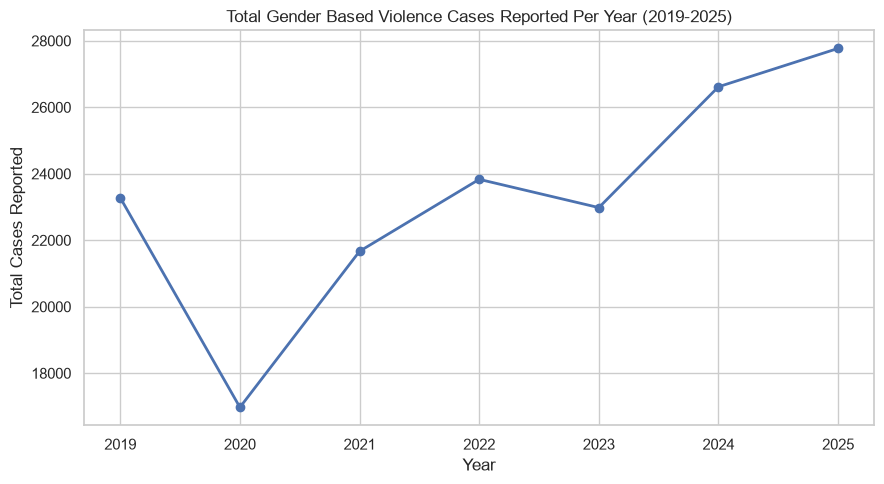

In [18]:
plt.figure(figsize = (9,5))
plt.plot(yearly.index, yearly.values, marker='o', linewidth = 2)
plt.title('Total Gender Based Violence Cases Reported Per Year (2019-2025)')
plt.xlabel('Year')
plt.ylabel('Total Cases Reported')

plt.xticks(yearly.index)
plt.tight_layout()
plt.savefig('../outputs/figures/yearly_totals.png', dpi=150)
plt.show()

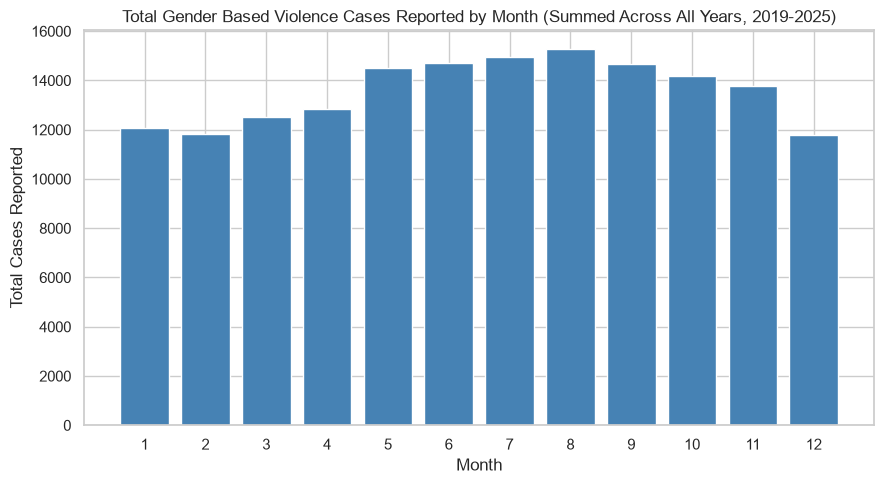

In [23]:
df['Month'] = df['Date'].dt.month

monthly_avg = df[df['Year'] != 2026].groupby('Month')['Cases_Reported'].sum()
monthly_avg

plt.figure(figsize = (9,5))
plt.bar(monthly_avg.index, monthly_avg.values, color='steelblue')
plt.title('Total Gender Based Violence Cases Reported by Month (Summed Across All Years, 2019-2025)')
plt.xlabel('Month')
plt.ylabel('Total Cases Reported')
plt.xticks(range(1,13))
plt.tight_layout()
plt.savefig('../outputs/figures/monthly_pattern.png')
plt.show()

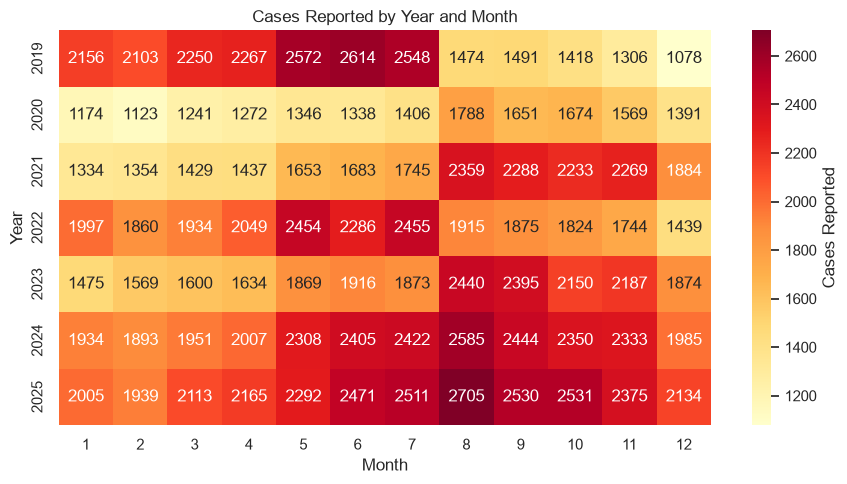

In [30]:
pivot = df[df['Year'] != 2026].pivot_table(
    index='Year', columns = 'Month', values = 'Cases_Reported', aggfunc='sum'
)

plt.figure(figsize = (9,5))
sns.heatmap(pivot, cmap='YlOrRd', annot=True, fmt='.0f', cbar_kws={'label': 'Cases Reported'})
plt.title('Cases Reported by Year and Month')
plt.xlabel('Month')
plt.ylabel('Year')
plt.tight_layout()
plt.savefig('../outputs/figures/year_month_heatmap.png', dpi=150)
plt.show()